In [1]:
import pandas as pd

train_df = pd.read_csv("../data/splits/train.csv")
val_df   = pd.read_csv("../data/splits/val.csv")
test_df  = pd.read_csv("../data/splits/test.csv")

print(len(train_df), len(val_df), len(test_df))
print("Classes:", train_df["label"].nunique())
train_df.head()

6073 1302 1302
Classes: 101


,filepath,label
0,data/raw/caltech-101/Faces_easy/image_0360.jpg,Faces_easy
1,data/raw/caltech-101/water_lilly/image_0022.jpg,water_lilly
2,data/raw/caltech-101/joshua_tree/image_0062.jpg,joshua_tree
3,data/raw/caltech-101/Motorbikes/image_0657.jpg,Motorbikes
4,data/raw/caltech-101/umbrella/image_0035.jpg,umbrella


In [2]:
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from tqdm import tqdm

def extract_hog_features(df, image_size=64):
    X = []
    for fp in tqdm(df["filepath"].tolist()):
        img = imread("../" + fp)  # 注意：notebook在notebooks/下，所以加 ../
        if img.ndim == 3:
            img = rgb2gray(img)
        img = resize(img, (image_size, image_size), anti_aliasing=True)

        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )
        X.append(feat)
    return np.array(X)

X_train = extract_hog_features(train_df, image_size=64)
X_val   = extract_hog_features(val_df, image_size=64)
X_test  = extract_hog_features(test_df, image_size=64)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

X_train.shape, X_val.shape, X_test.shape

100%|██████████████████████████████████████| 1302/1302 [00:03<00:00, 355.40it/s]


((6073, 1764), (1302, 1764), (1302, 1764))

In [3]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(X_train, y_train)

val_pred = svm.predict(X_val)
print("Val accuracy:", accuracy_score(y_val, val_pred))

Val accuracy: 0.6105990783410138


In [4]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../outputs/figures", exist_ok=True)

# Predict
test_pred = svm.predict(X_test)

# Accuracy
test_acc = accuracy_score(y_test, test_pred)
print("Test accuracy:", test_acc)

# Classification report
report = classification_report(y_test, test_pred, digits=4)
print(report)

# Save report
with open("../outputs/hog_svm_report.txt", "w") as f:
    f.write(report)

Test accuracy: 0.5952380952380952
                 precision    recall  f1-score   support

          Faces     0.8611    0.9394    0.8986        66
     Faces_easy     0.9403    0.9545    0.9474        66
       Leopards     0.7027    0.8667    0.7761        30
     Motorbikes     0.9597    0.9917    0.9754       120
      accordion     0.7500    0.7500    0.7500         8
      airplanes     0.9219    0.9833    0.9516       120
         anchor     0.0000    0.0000    0.0000         6
            ant     0.0000    0.0000    0.0000         6
         barrel     1.0000    0.5714    0.7273         7
           bass     0.0000    0.0000    0.0000         8
         beaver     0.1667    0.1429    0.1538         7
      binocular     0.0000    0.0000    0.0000         5
         bonsai     0.5500    0.5789    0.5641        19
          brain     0.4737    0.6000    0.5294        15
   brontosaurus     0.0000    0.0000    0.0000         6
         buddha     0.5789    0.8462    0.6875       

/Users/macbook/anaconda3/envs/caltech101/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbook/anaconda3/envs/caltech101/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbook/anaconda3/envs/caltech101/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

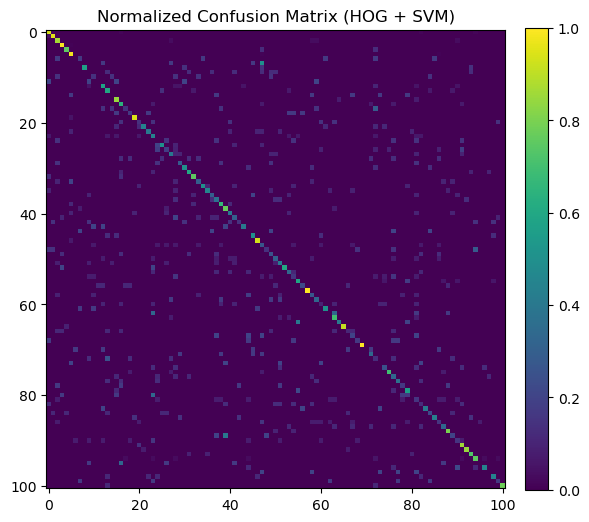

In [5]:
labels_sorted = sorted(train_df["label"].unique())

cm = confusion_matrix(y_test, test_pred, labels=labels_sorted)

# normalize by true class (row-wise)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,6))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix (HOG + SVM)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()

plt.savefig("../outputs/figures/hog_svm_confusion_norm.png", dpi=200)
plt.show()

In [6]:
label_to_idx = {l:i for i,l in enumerate(labels_sorted)}

y_true_idx = np.array([label_to_idx[y] for y in y_test])
y_pred_idx = np.array([label_to_idx[y] for y in test_pred])

per_class_acc = {}

for l in labels_sorted:
    idx = label_to_idx[l]
    mask = (y_true_idx == idx)
    per_class_acc[l] = (y_pred_idx[mask] == idx).mean()

per_class_acc_sorted = sorted(per_class_acc.items(), key=lambda x: x[1])

print("Worst classes:", per_class_acc_sorted[:10])
print("Best classes:", per_class_acc_sorted[-10:])

Worst classes: [('anchor', 0.0), ('ant', 0.0), ('bass', 0.0), ('binocular', 0.0), ('brontosaurus', 0.0), ('cougar_body', 0.0), ('crocodile', 0.0), ('gerenuk', 0.0), ('mayfly', 0.0), ('panda', 0.0)]
Best classes: [('Leopards', 0.8666666666666667), ('minaret', 0.9090909090909091), ('grand_piano', 0.9333333333333333), ('Faces', 0.9393939393939394), ('car_side', 0.9473684210526315), ('Faces_easy', 0.9545454545454546), ('airplanes', 0.9833333333333333), ('Motorbikes', 0.9916666666666667), ('laptop', 1.0), ('pagoda', 1.0)]


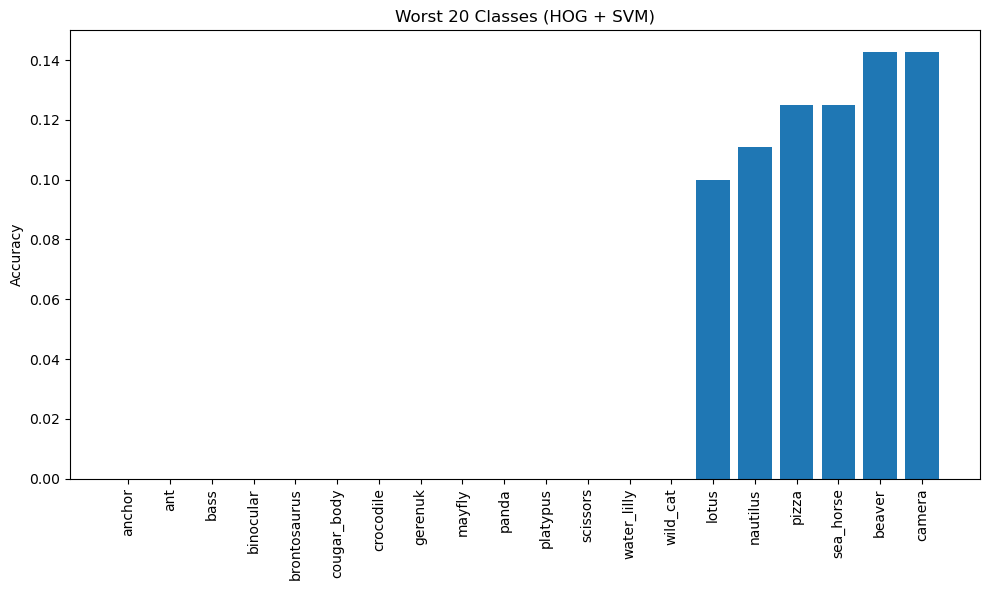

In [7]:
worst = per_class_acc_sorted[:20]

plt.figure(figsize=(10,6))
plt.bar([x[0] for x in worst], [x[1] for x in worst])
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Worst 20 Classes (HOG + SVM)")
plt.tight_layout()

plt.savefig("../outputs/figures/hog_svm_worst_classes.png", dpi=200)
plt.show()